<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 40px;
font-family: 'Segoe UI', sans-serif;
font-weight: 400;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<b style="color: #00cfff;">⚡</b>
<span style="color: #ffffff;">Exercícios Aprendizado Profundo</span>
</div>

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">3) Implemente e treine uma Rede Neural Convolucional (CNN) para resolver o problema de
classificação de objetos em imagens, utilizando a base de dados CIFAR-10, disponível em:
https://www.cs.toronto.edu/~kriz/cifar.html.
Apresente a curva do erro médio ao longo do treinamento, bem como a matriz de confusão do
modelo avaliado sobre o conjunto de testes.</span>
</div>

In [159]:
#PACOTES
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [160]:
#função dada em https://www.cs.toronto.edu/~kriz/cifar.html para puxar os dados
def load_data(file):
    with open(file, "rb") as fo:
        data_dict = pickle.load(fo, encoding="bytes")
    return data_dict


In [161]:
import os
current_dir = os.path.abspath(os.getcwd())

path1  = "cifar_data/data_batch_1"
path2  = "cifar_data/data_batch_2"
path3  = "cifar_data/data_batch_3"
path4  = "cifar_data/data_batch_4"
path5  = "cifar_data/data_batch_5"

data1 = load_data(path1)
data2 = load_data(path2)
data3 = load_data(path3)
data4 = load_data(path4)
data5 = load_data(path5)

images1 = data1[b"data"]
images2 = data2[b"data"]
images3 = data3[b"data"]
images4 = data4[b"data"]
images5 = data5[b"data"]

# labels dos 5 batches
labels1 = np.array(data1[b"labels"])
labels2 = np.array(data2[b"labels"])
labels3 = np.array(data3[b"labels"])
labels4 = np.array(data4[b"labels"])
labels5 = np.array(data5[b"labels"])

X = np.concatenate([images1, images2, images3, images4, images5], axis=0)   # (50000, 3072)
y = np.concatenate([labels1, labels2, labels3, labels4, labels5], axis=0)   # (50000,)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_180\876529372.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(fo, encoding="bytes")


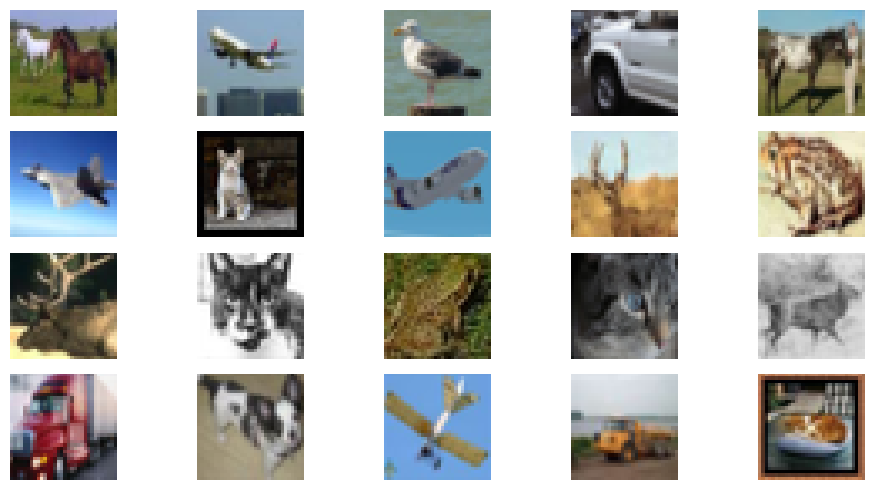

In [162]:
#PLOTANDO 20  figuras aleatórias
plt.figure(figsize=(10,5))

import random
figures = [random.randint(1, 40000) for _ in range(20)]
i = 0
for f in figures:
    plt.subplot(4, 5, i + 1)  
    img = X[f].reshape(3,32,32).transpose(1, 2, 0)
    plt.imshow(img)
    plt.axis('off')            #
    i += 1
plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">
Os labels são 10: 
        Avião
        Automóvel
        Pássaro
        Gato
        Veado
        Cachorro
        Sapo
        Cavalo
        Navio
        Caminhão
    </span>
</div>

In [163]:
from sklearn.model_selection import train_test_split
import tensorflow as tf


In [164]:
#SEPARANDO TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# CIFAR raw flat (R 1024, G 1024, B 1024)
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test  = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print("X train:", X_train.shape)  
print("X test:", X_test.shape)  
print("y train:", y_train.shape)  
print("y test:", y_test.shape)  

X train: (40000, 32, 32, 3)
X test: (10000, 32, 32, 3)
y train: (40000,)
y test: (10000,)


In [165]:

X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")

#definindo o batch
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.AUTOTUNE)


In [166]:
#estou usando o formato flat
for data_batch, labels_batch in train_dataset:
    print(data_batch.shape)
    print(labels_batch.shape)
    print(data_batch[0].shape)
    break

(32, 32, 32, 3)
(32,)
(32, 32, 3)


In [167]:
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling



In [ ]:
#OneHotEncoder
y_train = keras.utils.to_categorical(y_train.ravel(), num_classes=10)
y_test  = keras.utils.to_categorical(y_test.ravel(),  num_classes=10)


#Conv2D: é a convolução, que vai fazer a correlação invertida, que extrai padrões das imagens
#MaxPooling: pega o maior valor de pixel na região, monta uma imagem menor com a maiores valores
#permite achar relações maiores

model = keras.Sequential([
    keras.layers.Rescaling(1./255, input_shape=(32,32,3)),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    # keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # y em inteiros 0..9
    metrics=['accuracy']
)

model.summary()


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_20 (Rescaling)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/15
500/500 - 9s - 18ms/step - accuracy: 0.9279 - loss: 0.2126 - val_accuracy: 0.8851 - val_loss: 0.3789
Epoch 2/15
500/500 - 10s - 19ms/step - accuracy: 0.9408 - loss: 0.1748 - val_accuracy: 0.8763 - val_loss: 0.4137
Epoch 3/15
500/500 - 11s - 22ms/step - accuracy: 0.9495 - loss: 0.1500 - val_accuracy: 0.8705 - val_loss: 0.4395
Epoch 4/15
500/500 - 11s - 22ms/step - accuracy: 0.9568 - loss: 0.1257 - val_accuracy: 0.8580 - val_loss: 0.4928
Epoch 5/15
500/500 - 15s - 29ms/step - accuracy: 0.9633 - loss: 0.1113 - val_accuracy: 0.8493 - val_loss: 0.5444
Epoch 6/15
500/500 - 16s - 31ms/step - accuracy: 0.9696 - loss: 0.0924 - val_accuracy: 0.8347 - val_loss: 0.6236
Epoch 7/15
500/500 - 12s - 24ms/step - accuracy: 0.9737 - loss: 0.0825 - val_accuracy: 0.8413 - val_loss: 0.6304
Epoch 8/15
500/500 - 15s - 31ms/step - accuracy: 0.9764 - loss: 0.0730 - val_accuracy: 0.8239 - val_loss: 0.7167
Epoch 9/15


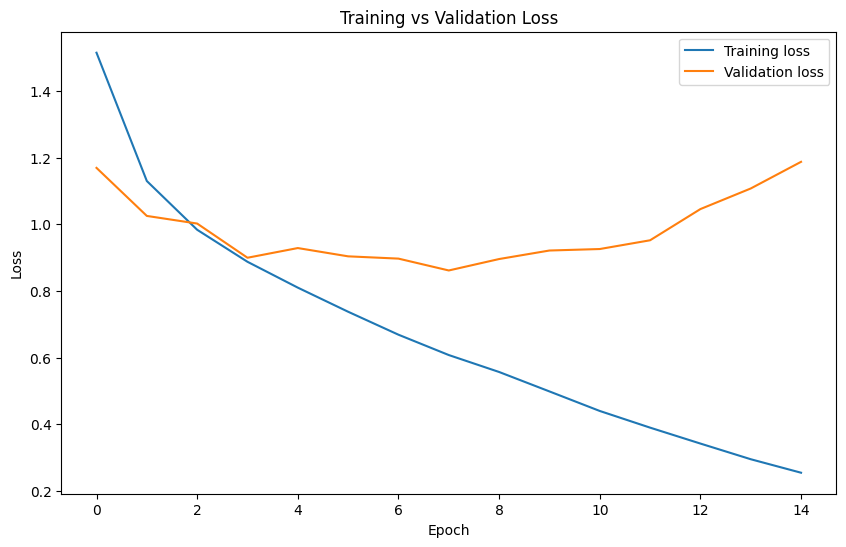

In [173]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label="Training loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()